# Task 4 — Place each item in the right stage

## 1. Placement
| Item | Stage | Justification |
|---|---|---|
| A Removing duplicate orders | ETL / Staging | A cleaning step done on the way in. |
| B CEO dashboard on a phone | BI Applications | A tool the end user looks at. |
| C Branch POS billing system | Source Systems | Operational system where the data is created. |
| D Sales star schema (date, branch, product) | Presentation Area | Dimensional model users query. |
| E HR team's staff Excel sheet | Source Systems | Data created and maintained outside the warehouse. |
| F Converting CL-150 to Cola 1.5L | ETL / Staging | Standardising/conforming codes to names. |
| G Weekly PDF report emailed to managers | BI Applications | A report delivered to users. |
| H Finance data mart | Presentation Area | A queryable, dimensional subject area. |

## 2. Architecture diagram (drawn by code)

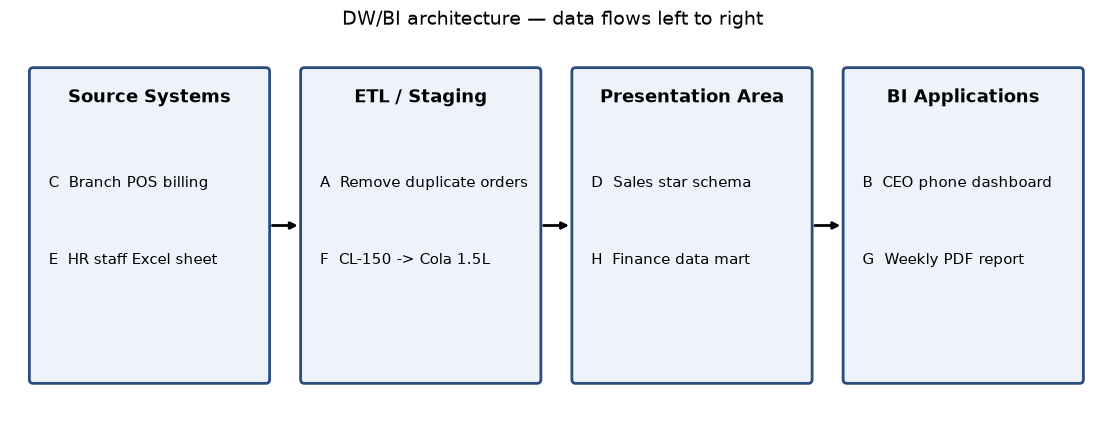

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(14,5)); ax.axis("off"); ax.set_xlim(0,14); ax.set_ylim(0,5)
stages=[("Source Systems",["C  Branch POS billing","E  HR staff Excel sheet"]),
        ("ETL / Staging",["A  Remove duplicate orders","F  CL-150 -> Cola 1.5L"]),
        ("Presentation Area",["D  Sales star schema","H  Finance data mart"]),
        ("BI Applications",["B  CEO phone dashboard","G  Weekly PDF report"])]
for i,(t,items) in enumerate(stages):
    x=0.3+i*3.5
    ax.add_patch(FancyBboxPatch((x,0.5),3,4,boxstyle="round,pad=0.05",fc="#eef3fb",ec="#2b4c7e",lw=2))
    ax.text(x+1.5,4.1,t,ha="center",fontsize=13,fontweight="bold")
    for j,it in enumerate(items): ax.text(x+0.2,3.0-j*1.0,it,fontsize=11)
    if i<3: ax.annotate("",xy=(x+3.45,2.5),xytext=(x+3.05,2.5),arrowprops=dict(arrowstyle="-|>",lw=2))
plt.title("DW/BI architecture — data flows left to right",fontsize=14); plt.savefig("task4_architecture.png",dpi=150,bbox_inches="tight"); plt.show()

## 3. Restaurant metaphor
Farms = **source systems** (raw ingredients); kitchen = **ETL / staging** (wash, cut, cook); serving counter = **presentation area** (ready, consistent dishes); tables = **BI applications** (where the diner consumes).

| Scenario | What goes wrong in a real warehouse |
|---|---|
| Diner wandering into the kitchen to take food off the stove | Users query the staging area directly: they see half-cleaned, duplicated or partially loaded data, and their queries can disturb the load. |
| Kitchen serving a dish without tasting it | Data is loaded without quality checks (no row counts, duplicate or null tests), so wrong numbers reach dashboards and are trusted. |
| Two kitchens cooking the same dish to different recipes | Separate ETL pipelines/marts define the same measure differently (e.g. "sales"), giving conflicting numbers — no conformed definitions. |

## 4. Kimball's goals violated in the Superstore case
- **Information must be easily accessible:** the CEO's report had to be run on the live checkout database, which was slow for both the report and the counters.
- **Information must be consistent:** three departments reported Rs 661.65 m, 283.70 m and 584.75 m for the same month.
- **The system must be a trusted, authoritative foundation for decisions:** branch files with `Rs` text amounts, duplicated and blank-category orders cannot be relied on for a Beverages total.

## 5. Item E — HR Excel sheet as a source system
**For:** a source system is simply where data originates; HR owns this data and it exists nowhere else, so the warehouse needs it. ETL already handles files.
**Against:** no enforced schema or data types, anyone can edit it, no audit trail, versions get copied around, and it depends on one person — it is the least controlled kind of source.

**Choice:** treat it as a legitimate source system, **conditionally** (assumption: HR is the only holder of this data).
**Required before trusting it:** a named owner; a fixed template with locked column names/types; a single shared location with versioning (no emailed copies); a unique staff ID per row; validation in staging (no duplicate IDs, no blanks in key fields, valid values); and a documented refresh schedule. Rows failing validation are rejected back to HR, not silently fixed.